# Cell-driven Niche Perturbation (CNP) Injection Simulation

This tutorial introduces the Cell-driven Niche Perturbation (CNP) framework for probing how targeted cellular perturbations reshape spatial microenvironments in the aging hippocampus.

We use mouse Stereo-seq data from Ma et al., Cell (2024) to demonstrate how cell-level perturbations can causally link cellular identity to niche organization during aging.

⸻

Dataset

Study
Spatial transcriptomic landscape unveils immunoglobulin-associated senescence as a hallmark of aging
Ma, Shuai et al., Cell, 2024

The dataset captures spatial gene expression patterns in the hippocampus of young (2-month-old) and aged (25-month-old) mice.

⸻

Regions of Interest (ROIs)

Selected hippocampal ROIs from young and aged mice are used as localized spatial contexts to analyze niche-level responses to perturbation.

⸻

CNP Perturbation Modes

1. Cell Replacement

Aged cells within a target niche are replaced by their young counterparts, partially overwriting the aged tissue context.
This mode evaluates how rejuvenated cellular identities reshape surrounding microenvironments.

2. Cell Injection

Young cells are introduced into aged ROIs without removing native aged cells.
This mode isolates how rejuvenating cues propagate through an intact aged structural substrate.

⸻

Evaluation

For both perturbation modes, we assess:
	•	Spatial remodeling within ROIs
	•	Cell- and niche-level embedding similarity to the young reference
	•	Microenvironmental responses across major cell types

⸻

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import seaborn as sns
from typing import Optional
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon_v2/BrainBeacon/")
from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.pipeline.perturbation import inject_cells_randomly, inject_cells_into_niche, plot_cosine_to_centroids_with_perturb, analyze_embedding_similarity_change_similarity_niche
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change, analyze_gene_reconstruction_change, compute_delta_cosine
from brainbeacon.utils import set_seed
import brainbeacon.configs.config as cfg
from brainbeacon.configs.config_train import config_train as cfg_train
from brainbeacon.utils import compute_density_token, compute_deviation_bin_rapid_v2
from brainbeacon.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig5_subfig"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


In [3]:
# =============================================================================
# 1. Dataset and Basic Setup
# =============================================================================
dataset_name = "niche2cell_injection"
specie = "mouse"  # NOTE: keep original variable name for compatibility
assay = "stereo"

# =============================================================================
# 2. Prior Knowledge / Paths
# =============================================================================
# Base directories
BASE_DIR = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/")

# Sync into cfg (assumes cfg / cfg_train already exist in your notebook/runtime)
cfg.DEFAULT_PATHS["BASE_DIR"] = str(BASE_DIR)
cfg.DEFAULT_PATHS["PRETRAIN_DIR"] = "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/"
cfg.DEFAULT_PATHS["PRIOR_DIR"] = cfg.DEFAULT_PATHS["PRETRAIN_DIR"]
cfg.DEFAULT_PATHS["GENE_DICT_PATH"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/model_h5ad_1211.h5ad"
)

# Path to the processed AnnData object used in this tutorial.
# The processed file (adata_outer_ensembl.h5ad) can be downloaded directly from:
# https://drive.google.com/file/d/1-z8J8xiRN0qD0preVQr8cAHKQXuScBp2/view?usp=drive_link
#
# Alternatively, the original raw Stereo-seq data can be obtained from the CNGBdb STOmics portal:
# https://db.cngb.org/stomics/datasets/STDS0000247/data
# Users may start from the raw data and follow their own preprocessing pipeline if desired.
adata_path = BASE_DIR / "data" / "adata_outer_ensembl.h5ad"  # adata_outer_ensembl / adata_inner_ensembl
gene_dict_path = Path(cfg.DEFAULT_PATHS["GENE_DICT_PATH"])
gene_mean_path = Path(
    "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"
)

# ESM embedding path
cfg_train["esm_embedding_path"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/esm2_embeddings_d5120.pt"
)

# Basic sanity checks (fail fast)
assert adata_path.exists(), f"adata_path not found: {adata_path}"
assert gene_dict_path.exists(), f"gene_dict_path not found: {gene_dict_path}"
assert gene_mean_path.exists(), f"gene_mean_path not found: {gene_mean_path}"
assert Path(cfg_train["esm_embedding_path"]).exists(), f"esm_embedding_path not found: {cfg_train['esm_embedding_path']}"

# =============================================================================
# 3. Pretrained Checkpoints
# =============================================================================
pretrain_dir = BASE_DIR / "pretrained"

bb_ckpt_name = "epoch_0_setp_800000.pt"
cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
# cellformer_ckpt_name = "cellformer.ckpt"      # CellPLM original checkpoint

bb_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt")
cellplm_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt")

assert bb_ckpt_path.exists(), f"bb_ckpt_path not found: {bb_ckpt_path}"
assert cellplm_ckpt_path.exists(), f"cellplm_ckpt_path not found: {cellplm_ckpt_path}"

# =============================================================================
# 4. Output Naming
# =============================================================================
cd_weight = 0.02
use_hvg = True
n_hvg = 5000

bb_ckpt_tag = bb_ckpt_name.replace(".pt", "").replace(".ckpt", "")
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_tag}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_tag}_cd{cd_weight}"

output_dir = BASE_DIR / "downstream_tasks" / "virtual_perturbation" / "outputs" / dataset_name / method_name
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 5. Load Data and (Optionally) Select Slices
# =============================================================================
full_adata = sc.read_h5ad(str(adata_path))

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]

# NOTE: Uncomment if you want to restrict to selected slices
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()

# =============================================================================
# 6. Derive Labels
# =============================================================================
def infer_cell_label(slice_name: str) -> Optional[str]:
    """Infer 'Young' / 'Old' from slice naming convention."""
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    if slice_name.startswith("Hippocampus_O"):
        return "Old"
    return None  # Unknown slice pattern

# Apply label + batch
adata.obs["cell_label"] = adata.obs["slice"].astype(str).map(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]

# Enforce categorical type (keeps only 'Young' and 'Old' as known categories)
adata.obs["cell_label"] = pd.Categorical(adata.obs["cell_label"], categories=["Young", "Old"])

Next, we select regions of interest (ROIs) to further investigate
how the perturbation reshapes local cellular niches after gene perturbation.
These ROIs enable a focused analysis of spatial and niche-level changes
induced by the perturbation.

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


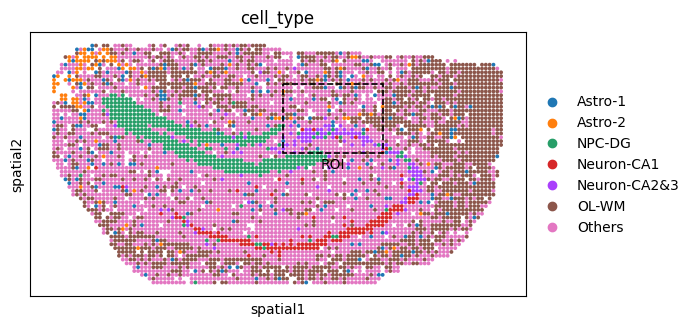

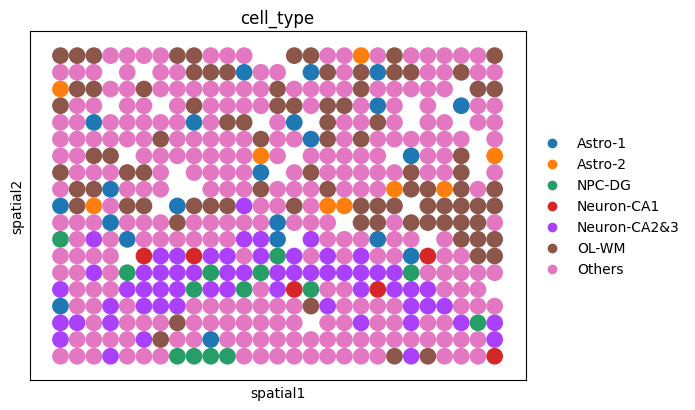

In [4]:
ol_cells = adata[adata.obs["slice"] == "Hippocampus_O_2_1"].copy()
ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    
    (ol_cells.obsm["spatial"][:, 1] > 10) &    
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
ol_cells.obs["cell_type"] = ol_cells.obs["cell_type"].astype("category")
categories = ol_cells.obs["cell_type"].cat.categories
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"], categories=categories, ordered=True
)

ol_cells.uns["cell_type_colors"] = ol_cells.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(categories)]
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

roi_coords = ol_roi.obsm["spatial"]
xmin, xmax = roi_coords[:, 0].min(), roi_coords[:, 0].max()
ymin, ymax = roi_coords[:, 1].min(), roi_coords[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2
os.makedirs(out_fig_dir, exist_ok=True)

fig_ol = sc.pl.spatial(
    ol_cells, color="cell_type", spot_size=1, show=False, return_fig=True
)
ax_ol = fig_ol.axes[0]
rect = Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--'
)
ax_ol.add_patch(rect)

ax_ol.text(
    xcenter, ymax + 5, "ROI",
    color='black', fontsize=10, ha='center', va='bottom'
)
fig_roi = sc.pl.spatial(
    ol_roi, color="cell_type", spot_size=1, show=False, return_fig=True
)

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


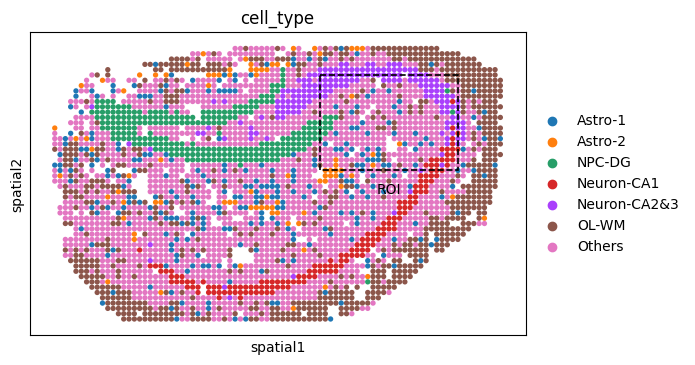

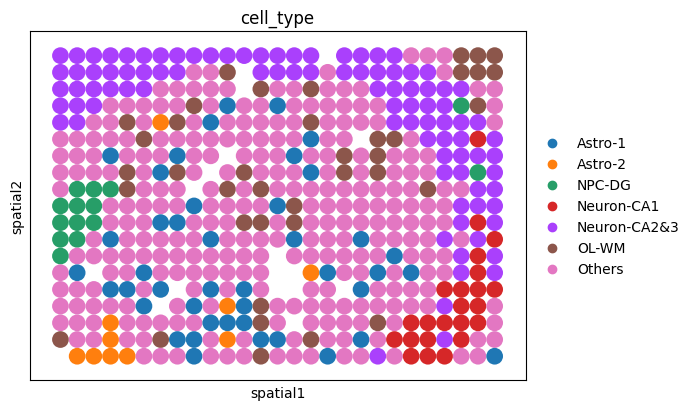

In [5]:
# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')
# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)

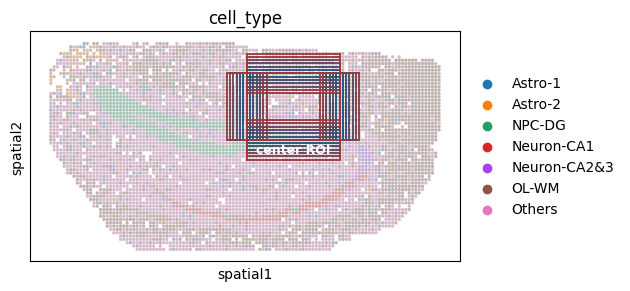

In [6]:
fig_ol = sc.pl.spatial(
    ol_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_ol = fig_ol.axes[0]

for c in ax_ol.collections:
    facecolors = c.get_facecolor()
    # Gray
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)   

# === ROI ===
ol_base_x, ol_base_y = (60, 88), (10, 30)
shifts = [(0, 0), (1, 0), (-1, 0), (0, 1), (0, -1),
           (2, 0), (-2, 0), (0, 2), (0, -2),
           (3, 0), (-3, 0), (0, 3), (0, -3),
           (4, 0), (-4, 0), (0, 4), (0, -4),
           (5, 0), (-5, 0), (0, 5), (0, -5),
           (6, 0), (-6, 0), (0, 6), (0, -6)]

import matplotlib.colors as mcolors
start_color = "#145583" 
end_color   = "#A13939" 
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

# ===  ROI box===
for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = ol_base_x[0] + dx, ol_base_x[1] + dx
    ymin, ymax = ol_base_y[0] + dy, ol_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_ol.add_patch(rect)

# ===  ROI anno ===
ax_ol.text(
    np.mean(ol_base_x),
    ol_base_y[1] + 5,
    "center ROI",
    color='white',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/ol_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

In [7]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [8]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [9]:
print(ol_roi)
print(y_roi)
print(adata)
print(adata_fov_OL)

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'deviation_bin', 'neighbor_gene_distribution', 'spatial_um'
    layers: 'lognorm', 'raw_count'
AnnData object with n_obs × n_vars = 495 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

In [10]:
# ========== Run Original Inference ==========
# This step constructs the baseline (unperturbed) reference by running inference
# on the original data, which serves as the control condition for all subsequent
# perturbation analyses.
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")

Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.003814876079559326 min


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.32s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.13 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:12<00:00,  1.33it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
Time cost:  0.3405189077059428
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


...

Epoch 98 | Train loss: 6803.6355 | Valid loss: 6843.8608


100%|██████████| 100/100 [00:58<00:00,  1.71it/s]

Epoch 99 | Train loss: 6832.2544 | Valid loss: 6840.0640
After filtering, 20316 genes remain.



... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slic

In [11]:
# =============================================================================
# CNP Perturbation (Injection): Young NPC-DG cells injected into an aged niche
# =============================================================================
# This block demonstrates the "injection" mode in the Cell-driven Niche Perturbation (CNP) framework,
# using NPC-DG cells as an example.
#
# Conceptually, this perturbation mimics a stem cell–like therapeutic scenario:
# young NPC-DG cells are sampled from a young mouse hippocampal slice and then
# injected into a region of interest (ROI) from an aged mouse.
#
# Key characteristics of the injection operation:
# - The target cell type (NPC-DG) is extracted from the young slice and used as donor cells.
# - Donor cells are injected into the aged ROI without removing native aged cells.
# - Injected cells are randomly distributed within the ROI to simulate stochastic
#   engraftment and spatial integration.
# - The number of injected cells (n_inject), their spatial locations, and the
#   injected cell type can be flexibly controlled.
#
# This setup enables systematic investigation of how rejuvenating cellular cues
# propagate through an intact aged microenvironment.
celltype = "NPC-DG"

old_slice  = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_O_2_1"]
young_pool = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]

perturbed_adata = inject_cells_randomly(
    target_adata = old_slice,
    donor_adata  = young_pool,
    celltype     = celltype,
    spatial_key  = "spatial",
    n_inject=50,
    random_state=4
)
pert_input = ad.concat(
    [perturbed_adata, adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]],
    join="outer"
)
output_prefix_perturb = "inject_young_NPC-DG_to_old"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
pert_input.write(perturb_input_adata_path)
print(f"Injected input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb.write(perturb_result_adata_path)
print(f"Perturbation result adat2a saved to: {perturb_result_adata_path}")


... storing 'cell_type' as categorical
... storing 'injected_celltype' as categorical


Injected input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_input.h5ad
before quality control adata shape: (1026, 20318)
After HVG (5000) selection: (1026, 5000)
Computing cell density...
compute_density_token time:  0.003991528352101644 min


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 1026
Preprocessing time: 0.04 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 17/17 [00:11<00:00,  1.50it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_embeddings.npz
Time cost:  0.3015148401260376
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes rema

... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/niche2cell_injection/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/inject_young_NPC-DG_to_old_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 1026 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch

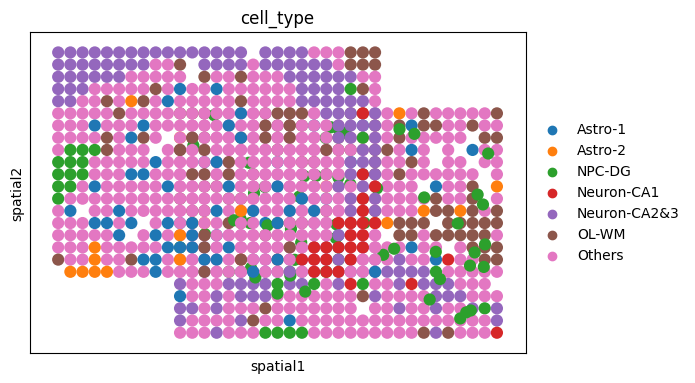

In [12]:
sc.pl.spatial(adata_perturb, color="cell_type", spot_size=1)

In [13]:
adata_injected_celltype = adata_perturb[adata_perturb.obs["injected"].notna()].copy()
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()
SLICE_OLD   = "Hippocampus_O_2_1"
SLICE_YOUNG = "Hippocampus_Y_2_1"
res_target = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori, adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG, target_slice_old=SLICE_OLD,
    target_celltype="NPC-DG", embedding_key="X_emb"
)

In [14]:
res_target

{'cosine': (np.float32(0.22743581), np.float32(0.23550425)),
 'euclidean': (np.float32(13.489248), np.float32(13.3988085)),
 'emd': (np.float64(0.41492335602765706), np.float64(0.4126618433414007)),
 'mmd': (np.float32(0.14571342), np.float32(0.14595458))}

In [15]:

result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG,
    target_slice_old=SLICE_OLD,
    target_celltype="NPC-DG",
    embedding_key="X_emb"
)
sim_ori_final, sim_perturb_final = result["cosine"]
dist_ori_final, dist_perturb_final = result["euclidean"]
emd_ori_final, emd_perturb_final = result["emd"]
mmd_ori_final, mmd_perturb_final = result["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))

Cosine similarity: before KO = 0.1176, after KO = 0.1268
Euclidean distance: before KO = 12.8969, after KO = 12.8077
Wasserstein distance (EMD): before KO = 0.3651, after KO = 0.3624
MMD: before KO = 0.0043, after KO = 0.0043


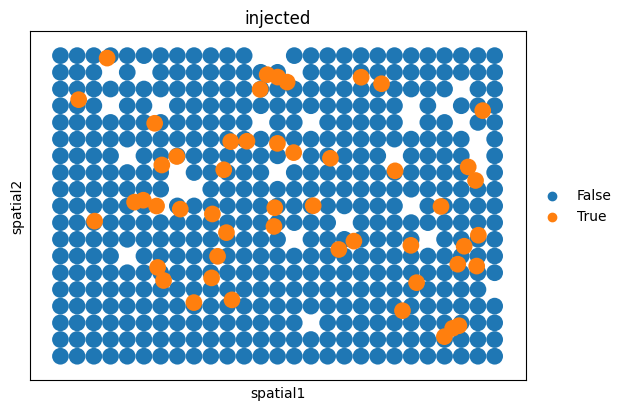

In [16]:
sc.pl.spatial(adata_injected_celltype, color="injected", spot_size=1)

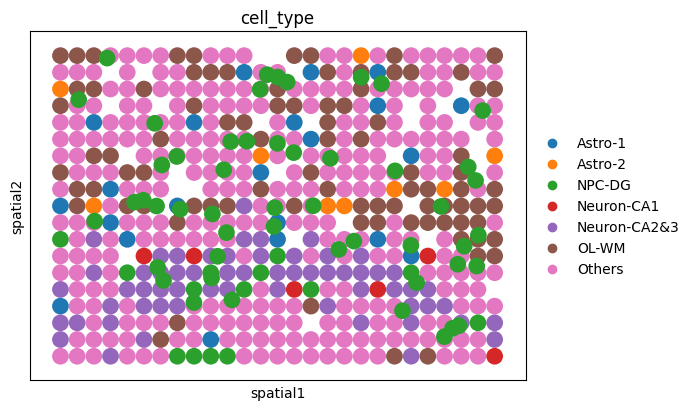

In [17]:
fig = sc.pl.spatial(
    adata_injected_celltype,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
# fig.savefig(os.path.join(out_fig_dir,"roi_injected_celltype_NPC-DG.pdf"), bbox_inches="tight")
# plt.close(fig)

In [18]:
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)

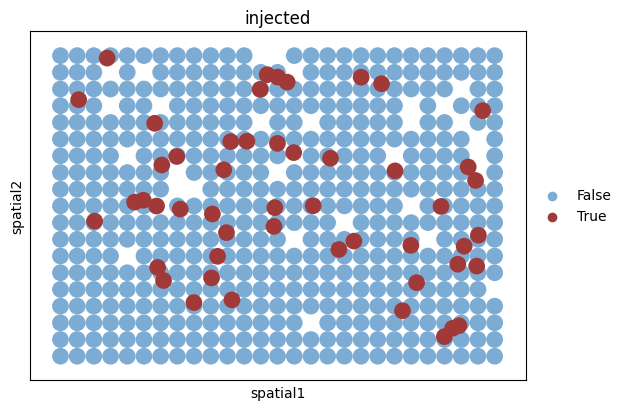

In [19]:
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
custom_colors = ["#7CACD4", "#A13939"]  
adata_injected_celltype.uns["injected_colors"] = custom_colors  


fig = sc.pl.spatial(
    adata_injected_celltype,
    color="injected",
    spot_size=1,
    show=False,
    return_fig=True
)
# fig.savefig(os.path.join(out_fig_dir,"roi_injected_custom_NPG-DG.pdf"), bbox_inches="tight")
# plt.close(fig)

In [20]:
result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG,
    target_slice_old=SLICE_OLD,
    target_celltype="OL-WM",
    embedding_key="X_emb"
)

In [21]:
adata_perturb_sub.obs["injected"]

61_11-Hippocampus_O_2_1    False
61_12-Hippocampus_O_2_1    False
61_13-Hippocampus_O_2_1    False
61_14-Hippocampus_O_2_1    False
61_15-Hippocampus_O_2_1    False
                           ...  
87_24-Hippocampus_O_2_1    False
87_26-Hippocampus_O_2_1    False
87_27-Hippocampus_O_2_1    False
87_28-Hippocampus_O_2_1    False
87_29-Hippocampus_O_2_1    False
Name: injected, Length: 481, dtype: bool

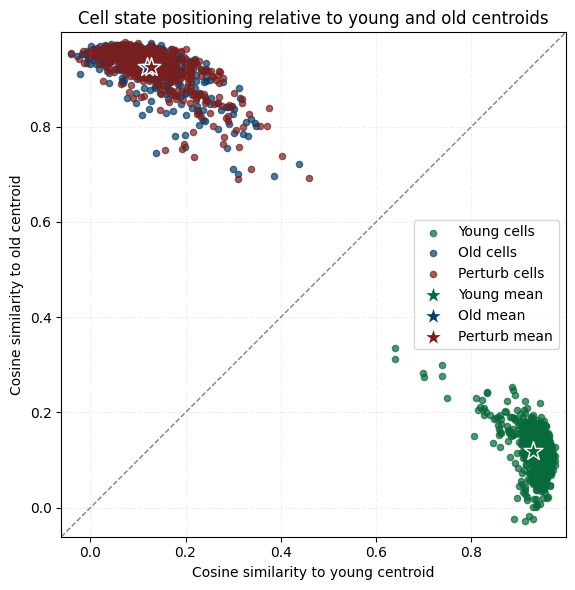

In [22]:
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_sub,
    slice_young=SLICE_YOUNG,
    slice_old=SLICE_OLD,
    celltype_key="cell_type",
    emb_key="X_emb",
    agg_by_celltype=False,   # set to True to aggregate by cell type
    # save_path="cosine_scatter_NPC-DG.pdf"
)